### **Work Breakdown**:

* Anastasiia Yablunovska - SVD implementation (25%)
* Anastasia Liubenchuk - SVD of symmetric matrices (25%)
* Mykhailo Rykhalskyi - Image compression using SVD (25%)
* Mariia Hamaniuk - Results (25%)


### **Submission rules**:
1. The completed assignment should be prepared as s a Jupyter Notebook (.ipynb file). Please make a copy of this notebook for your team. Make sure you opened it via UCU email address. Submit the Jupyter Notebook (.ipynb file) to **lms**.
2. Please execute all the cells before submission; make sure there are no errors, everything has been generated, and all numerical answers calculated.
3. There should be only one submission per team. However, don't forget to choose a person from your team who would submit the task, and make sure that the names of all team members are listed in the notebook. Teammates not mentioned in the notebook will not be graded for this lab.
4. You also need to provide a work breakdown structure estimating the efforts of each team member. Please provide it at the top of your notebook. If you do not provide the work breakdown, the points will be reducted from your work.
5. The final deadline is specified on LMS.

**IMPORTANT**: If you submit your assignment after this time and date, it will not be graded.

# Image compression with SVD

The singular value decomposition of a matrix A is the factorization of A into the
product of three matrices:
\begin{align}
 A = UDV^T,
 \end{align}
where the columns of U and V are orthonormal and
the matrix D is diagonal with positive real entries. The SVD is useful in many tasks. First, in many applications, the data matrix A is close to a
matrix of low rank and it is useful to find a low rank matrix which is a good approximation
to the data matrix. You will show that from the singular value decomposition of A, we can get the matrix B of rank k which best approximates A; in fact, we can do this for every
k. Also, singular value decomposition is defined for all matrices (rectangular or square) unlike spectral decomposition, although the latter one is used more commonly in Linear Algebra.

Considering that any image can be represented as a rectangular matrix, you can find the best rank k approximation of this image using SVD. The idea is that by significantly reducing the storage space, you can still preserve a very good quality of the image

In [48]:
try:
    from google.colab.patches import cv2_imshow
except ImportError:
    import matplotlib.pyplot as plt
    from IPython.display import display, clear_output
    def cv2_imshow(img):
        arr = img.astype('uint8') if img.dtype != 'uint8' else img
        if arr.ndim == 3:
            arr = arr[:, :, ::-1]
        plt.close('all')
        fig = plt.figure(figsize=(6, 6))
        plt.imshow(arr, cmap='gray' if arr.ndim == 2 else None)
        plt.axis('off')
        plt.show()
import cv2 as cv
import numpy as np
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widget

import os

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widget
from skimage.metrics import structural_similarity as ssim
from scipy.fft import dctn, idctn


### SVD implementation (0.5)

Implement a function to compute SVD of the matrix.

Do not use the built-in functions; instead, compare your solution with the built-in one.

*Hint:* one of the simpliest methods for finding eigenvalues and eigenvectors of the matrix is [Power Iteration](https://en.wikipedia.org/wiki/Power_iteration). Hovewer, you may try some advanced methods :)

In [49]:
def power_iteration(A, num_iterations=1000, tol=1e-10):
    n = A.shape[0]
    b = np.random.rand(n)
    b = b / np.linalg.norm(b)

    eigenvalue = 0.0
    for _ in range(num_iterations):
        b_new = A @ b
        eigenvalue_new = np.dot(b, b_new)
        b_new_norm = np.linalg.norm(b_new)
        if b_new_norm < 1e-14:
            break
        b_new = b_new / b_new_norm
        if abs(eigenvalue_new - eigenvalue) < tol:
            eigenvalue = eigenvalue_new
            b = b_new
            break
        eigenvalue = eigenvalue_new
        b = b_new

    eigenvalue = float(np.dot(b, A @ b))
    return eigenvalue, b


def complete_orthonormal_basis(cols, dimension, tol=1e-12):
    basis = []

    for col in cols:
        v = np.asarray(col, dtype=float).copy()
        for q in basis:
            v -= np.dot(q, v) * q
        norm = np.linalg.norm(v)
        if norm > tol:
            basis.append(v / norm)

    for i in range(dimension):
        v = np.eye(dimension)[:, i]
        for q in basis:
            v -= np.dot(q, v) * q
        norm = np.linalg.norm(v)
        if norm > tol:
            basis.append(v / norm)
        if len(basis) == dimension:
            break

    return np.column_stack(basis)


def svd(A, num_iterations=1000, tol=1e-12):
    A = np.asarray(A, dtype=float)
    m, n = A.shape
    k = min(m, n)

    use_right_vectors = n <= m
    G = A.T @ A if use_right_vectors else A @ A.T

    singular_values = []
    eigenvectors = []
    G_deflated = G.copy()

    for _ in range(k):
        eigval, eigvec = power_iteration(G_deflated, num_iterations, tol)
        if eigval < 0:
            eigval = 0.0
        singular_values.append(np.sqrt(eigval))
        eigenvectors.append(eigvec)
        G_deflated = G_deflated - eigval * np.outer(eigvec, eigvec)

    order = np.argsort(singular_values)[::-1]
    Sigma_vals = np.array([singular_values[i] for i in order])
    eigenvectors = [eigenvectors[i] for i in order]

    U_cols = []
    V_cols = []

    if use_right_vectors:
        V_cols = eigenvectors
        for sigma, v in zip(Sigma_vals, V_cols):
            if sigma > tol:
                U_cols.append((A @ v) / sigma)
    else:
        U_cols = eigenvectors
        for sigma, u in zip(Sigma_vals, U_cols):
            if sigma > tol:
                V_cols.append((A.T @ u) / sigma)

    U = complete_orthonormal_basis(U_cols, m, tol)
    V = complete_orthonormal_basis(V_cols, n, tol)

    return U, Sigma_vals, V.T


Explain in detailes the chosen method for finding SVD.


---

The chosen method is Power Iteration with Deflation.

SVD of A is defined as $A = U\Sigma V^T$, where columns of V are eigenvectors of $A^T A$, columns of U are eigenvectors of $A A^T$, and singular values are $\sigma_i = \sqrt{\lambda_i}$.  
To avoid working with a large matrix, we choose which Gram matrix to diagonalize based on the shape of A:

* k = min( m, n)
* If k = n: G = $A^T A$ (used when n $\le$ m)
* Else: G = $A A^T$ (used when m < n)

This ensures Power Iteration always runs on the smaller of the two symmetric matrices, reducing computational cost. Eigenvectors of the chosen G give us either the right singular vectors V (if $G = A^T A$) or the left singular vectors U (if $G = A A^T$), and the other set is recovered via $u_i = \frac{A v_i}{\sigma_i}$ or $v_i = \frac{A^T u_i}{\sigma_i}$.

### Power Iteration
For a symmetric PSD matrix G, Power Iteration finds the dominant eigenpair $(\lambda_1, v_1)$:
1. Initialize a random unit vector $b_0$.
2. Repeatedly apply: $b_{k+1} = \frac{G b_k}{\|G b_k\|}$.
3. Estimate the eigenvalue via the Rayleigh quotient: $\lambda \approx b^T G b$.
4. Stop when $|\lambda_{new} - \lambda_{old}| < \text{tolerance}$.

Convergence rate is geometric with ratio $(\lambda_2/\lambda_1)^k$ - the larger the gap between the two biggest eigenvalues, the faster it converges.

### Deflation
After finding $(\lambda_1, v_1)$, the component is subtracted from $G$:
$$G \leftarrow G - \lambda_1 v_1 v_1^T$$
This zeros out the first eigenvalue, so the next Power Iteration converges to $(\lambda_2, v_2)$, and so on for all k eigenpairs.

### Assembly
* Singular values: $\sigma_i = \sqrt{\lambda_i}$.
* If $G = A^T A$: right vectors $v_i$ are direct, left vectors $u_i = \frac{A v_i}{\sigma_i}$.
* If $G = A A^T$: left vectors $u_i$ are direct, right vectors $v_i = \frac{A^T u_i}{\sigma_i}$.
* Full U and V matrices are completed by adding missing orthonormal basis vectors.

### Numerical notes
Power Iteration is simple and works well here because $A^T A$ and $A A^T$ are symmetric positive semidefinite. However, it is an iterative numerical method, so the result is approximate. It converges fastest when the largest eigenvalue is clearly separated from the next one. If singular values are very close, convergence can be slower and the singular vectors are not unique. The implementation also avoids division by nearly-zero singular values and completes the missing zero-singular-value subspaces with an orthonormal basis, so zero or rank-deficient matrices do not crash.



---



Explain why finding the roots of characteristic polynomial for finding eigenvalues is not always the best choice.

---


For an n×n matrix, eigenvalues are defined as roots of det(A − λI) = 0, which expands into a degree-n polynomial. While this works perfectly on paper, in practice it has serious issues:

1. When you expand det(A − λI), the resulting coefficients can be huge numbers, even if the eigenvalues themselves are small. A tiny floating-point rounding error in one coefficient can shift the roots significantly. Example: a 20×20 matrix with eigenvalues {1, 2, ..., 20} where changing one coefficient by 2⁻²³ moves some roots by several units.

2. No formula for n ≥ 5. For polynomials of degree 5 and higher, there is no general algebraic solution. So you are forced to use iterative numerical root-finding anyway - which introduces additional errors.

3. Computing the full characteristic polynomial first and then finding its roots is doing the work twice. Iterative methods like Power Iteration or QR algorithm find eigenvalues directly from the matrix in O(n³) operations, without the intermediate polynomial step.

4. If two eigenvalues are close to each other, the polynomial is nearly flat near that root, making numerical solvers converge very slowly or fail entirely.


---


### SVD of symmetric matrices (0.5 pts)

Here you have a symmetric matrix A. Compute a full SVD of this matrix.

In [50]:
A = np.array([[1, 2, 3, 4], [2, 7, 4, 5], [3, 4, 3, 8], [4, 5, 8, 3]], dtype=float)

U, s, Vt = svd(A)

U_np, s_np, Vt_np = np.linalg.svd(A)

print("Our SVD")
print("U:\n", U)
print("Singular values:", s)
print("V^T:\n", Vt)

print("\nNumPy SVD")
print("Singular values:", s_np)

D = np.diag(s)
A_reconstructed = U @ D @ Vt
print("\nReconstructed matrix A:")
print(np.round(A_reconstructed, 6))
print("\nOriginal matrix A:")
print(A)
print("\nMax reconstruction error:", np.max(np.abs(A - A_reconstructed)))

Our SVD
U:
 [[ 0.30461046 -0.14903379  0.31295055 -0.88716591]
 [ 0.54242371 -0.07127123 -0.83165076 -0.09515223]
 [ 0.53433563 -0.64331013  0.35591771  0.41708524]
 [ 0.57225381  0.74757035  0.28938132  0.17298151]]
Singular values: [17.33847234  5.15839249  2.79573697  0.97581683]
V^T:
 [[ 0.30461046  0.54242371  0.53433563  0.57225381]
 [ 0.14903378  0.07127125  0.64331012 -0.74757035]
 [ 0.31295055 -0.83165076  0.35591772  0.28938131]
 [ 0.88716591  0.09515222 -0.41708524 -0.17298151]]

NumPy SVD
Singular values: [17.33847234  5.15839249  2.79573697  0.97581683]

Reconstructed matrix A:
[[1. 2. 3. 4.]
 [2. 7. 4. 5.]
 [3. 4. 3. 8.]
 [4. 5. 8. 3.]]

Original matrix A:
[[1. 2. 3. 4.]
 [2. 7. 4. 5.]
 [3. 4. 3. 8.]
 [4. 5. 8. 3.]]

Max reconstruction error: 2.5084506916073224e-08


Explain what matrices did you get as a result. What can you say about singular values of this matrix (about its eigenvalues)?

As a result of SVD decomposition of matrix A, we obtain three matrices U, $\Sigma$, $V^T$ such that:

$$A = U \Sigma V^T$$

Matrix U is an $m \times m$ orthogonal matrix whose columns are left singular vectors of A. Orthogonality means:

$$U^T U = U U^T = I$$

Matrix $\Sigma$ is an $m \times n$ diagonal matrix with non-negative real entries $\sigma_1 \geq \sigma_2 \geq \dots \geq \sigma_r > 0$ on the diagonal, singular values of A. In our case A is $4 \times 4$, so $\Sigma$ is also $4 \times 4$.

Matrix $V^T is an $n \times n$ orthogonal matrix whose rows are called right singular vectors of A:

$$V^T V = V V^T = I$$

Since A is symmetric ($A = A^T$), a special relationship holds between U and V. Recall that singular values are defined as square roots of eigenvalues of $A^T A$:

$$\sigma_i = \sqrt{\lambda_i(A^T A)}$$

But since $A = A^T$, we have $A^T A = A^2$, so:

$$\sigma_i = \sqrt{\lambda_i(A^2)} = |\lambda_i(A)|$$

Therefore, singular values of a symmetric matrix equal the absolute values of its eigenvalues.

Furthermore, since A is symmetric, the left and right singular vectors coincide (up to sign):

$$U = V$$

which means $V^T = U^T$, and the decomposition becomes:

$$A = U \Sigma U^T$$

In [51]:
eigenvalues, eigenvectors = np.linalg.eig(A)

idx = np.argsort(-np.abs(eigenvalues))
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigenvalues:", np.round(eigenvalues, 6))
print("Singular values:", np.round(s, 6))
print("Absolute values of eigenvalues:", np.round(np.abs(eigenvalues), 6), "\n")

D_eig = np.diag(eigenvalues)
A_spectral = eigenvectors @ D_eig @ eigenvectors.T
print("Reconstruction via spectral decomposition:")
print(np.round(A_spectral, 6))

print("U (from SVD):\n", np.round(U, 6))
print("Q (eigenvectors):\n", np.round(eigenvectors, 6))

Eigenvalues: [17.338472 -5.158392  2.795737 -0.975817]
Singular values: [17.338472  5.158392  2.795737  0.975817]
Absolute values of eigenvalues: [17.338472  5.158392  2.795737  0.975817] 

Reconstruction via spectral decomposition:
[[1. 2. 3. 4.]
 [2. 7. 4. 5.]
 [3. 4. 3. 8.]
 [4. 5. 8. 3.]]
U (from SVD):
 [[ 0.30461  -0.149034  0.312951 -0.887166]
 [ 0.542424 -0.071271 -0.831651 -0.095152]
 [ 0.534336 -0.64331   0.355918  0.417085]
 [ 0.572254  0.74757   0.289381  0.172982]]
Q (eigenvectors):
 [[-0.30461  -0.149034 -0.312951 -0.887166]
 [-0.542424 -0.071271  0.831651 -0.095152]
 [-0.534336 -0.64331  -0.355918  0.417085]
 [-0.572254  0.74757  -0.289381  0.172982]]


How $SVD$ relates to matrises $Q, D, Q^T$ in spectral decomposition of this matrix? Are they identical? If they are, can you say that SVD of symmetric matrices always corresponds to its spectral decomposition? If not, then is it possible to find such symmetric matrises that SVD and spectral decomposition are identical?

The spectral decomposition of a symmetric matrix A is:

$$A = Q D Q^T$$

where Q is an orthogonal matrix of eigenvectors and $D = \text{diag}(\lambda_1, \lambda_2, \lambda_3, \lambda_4)$ is a diagonal matrix of eigenvalues.

The SVD of the same matrix is:

$$A = U \Sigma V^T$$

where $\Sigma = \text{diag}(\sigma_1, \sigma_2, \sigma_3, \sigma_4)$ contains singular values $\sigma_i = |\lambda_i|$.

In general, SVD and spectral decomposition are not identical:

1. SVD requires all diagonal entries of $\Sigma$ to be non-negative: $\sigma_i \geq 0$
2. Eigenvalues $\lambda_i$ can be negative for a symmetric matrix that is not positive semi-definite

For our matrix A, some eigenvalues are negative. In this case, SVD "corrects" the sign by flipping the corresponding columns of U or V. Concretely, for each negative eigenvalue $\lambda_i < 0$:

$$\sigma_i = |\lambda_i| = -\lambda_i, \quad \mathbf{u}_i \to -\mathbf{u}_i \text{ or } \mathbf{v}_i \to -\mathbf{v}_i$$

so that the product $\sigma_i \mathbf{u}_i \mathbf{v}_i^T$ still correctly reconstructs A.

When do they coincide exactly?

SVD and spectral decomposition are identical if and only if A is positive semi-definite, i.e., all eigenvalues satisfy $\lambda_i \geq 0$. In that case:

$$\sigma_i = \lambda_i \geq 0 \implies \Sigma = D, \quad U = V = Q$$

and the two decompositions become the same:

$$A = U \Sigma V^T = Q D Q^T$$

For a symmetric matrix A with mixed-sign eigenvalues (as in our case), SVD and spectral decomposition share the same eigenvectors Q = U = V (up to sign flips in columns corresponding to negative eigenvalues), but differ in $\Sigma$ vs D: SVD stores $|\lambda_i|$ while spectral decomposition stores $\lambda_i$.

### Image compression using SVD (1 pts)

Upload the picture of a dog.

Image shape: (900, 720, 3)


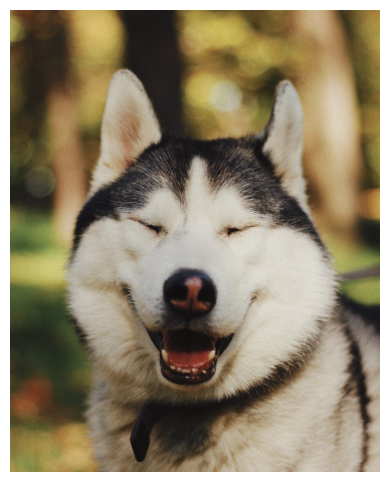

In [52]:
path = "happy-dog.jpg" if os.path.exists("happy-dog.jpg") else "../happy-dog.jpg"
image = cv.imread(path)
image = image.astype('float32')
print("Image shape:", image.shape)
cv2_imshow(image)


Complete the below function for finding a reduced SVD of a given matrix. (You may use the functions for finding eigenvalues of the matrix). Highlight the key differences between SVD and the reduced version of it.

In [53]:
def reduced_svd(A):
    """
    Input: any matrix A
    Returns: tuple of matrix U, array of singular values and matrix V.T
    """
    A = np.asarray(A, dtype=float)
    U, s, Vt = svd(A)
    tol = max(A.shape) * np.finfo(float).eps * (s.max() if s.size else 0.0)
    r = int(np.sum(s > tol))
    return U[:, :r], s[:r], Vt[:r, :]


_test = np.random.RandomState(0).randn(6, 4)
_U, _s, _Vt = reduced_svd(_test)
print("Max Reconstruction error:", np.max(np.abs(_test - _U @ np.diag(_s) @ _Vt)))
print("Shapes:\n U:", _U.shape, "s:", _s.shape, "Vt:", _Vt.shape)


Max Reconstruction error: 4.896406380350271e-08
Shapes:
 U: (6, 4) s: (4,) Vt: (4, 4)


The reduced $SVD$ basically chops off all the unimportant data: if a matrix A is of rank r, it has only r positive singular values. Other are zeros.
Thus, the reduced SVD gets rid of those zero values $\sigma_i$ and corresponding left and right singular vectors that results in $m \times r$ matrix U,
$r \times r$ matrix $\Sigma$ and $r \times n$ matrix $V^T$.

Inspite of that, the reduced SVD still returns us the matrix A!

Complete the function below. It should output the k-rank approximation of the given image using previously written SVD function. Use the slider to see how the image quality changes as we increase/decrease k.

For simplification, you can convert your image to a grayscale. However, it will be appreciated if you work with RGB channels (it is possible that you'll need to modify the method below a little).

In [ ]:
_channels = [reduced_svd(image[:, :, c]) for c in range(image.shape[2])]
_max_k = min(len(_channels[c][1]) for c in range(image.shape[2]))


@interact(k=widget.IntSlider(min = 1, max = _max_k, value = 100, continuous_update=False), image=fixed(image))
def k_rank_compressed_image(k, image):
    approximated = np.empty_like(image)
    for c, (U, s, Vt) in enumerate(_channels):
        kk = min(k, len(s))
        approximated[:, :, c] = (U[:, :kk] * s[:kk]) @ Vt[:kk, :]
    np.clip(approximated, 0, 255, out=approximated)
    cv2_imshow(approximated)


interactive(children=(IntSlider(value=100, continuous_update=False, description='k', max=720, min=1), Output()…

In general, compressing the image to 60-80% percent of its original size lowers its quality but human eye won't be even able to notice it. Therefore, we can win in storage while keeping almost the same image quality. Find out the range of  k 's which result in keeping only 60-80% of the size of the original image. For what  k 's there is no reason to use SVD for the sake of reducing storage space?


The number of scalars stored by a rank-k SVD approximation of an $m \times n$ image (per channel) is

$$\text{size}(k) \;=\; k\,(m + n + 1),$$

while the raw image takes $m \cdot n$ values per channel.  Solving $k(m+n+1) = \alpha\, m n$ for $\alpha = 0.6$ and $\alpha = 0.8$ gives the band reported above by the cell: every k in $[\texttt{lower\_bound\_k},\; \texttt{upper\_bound\_k}]$ stores 60–80 % of the original data, which empirically still looks essentially indistinguishable from the original to a human eye.

The break-even point is

$$k^{*} \;=\; \frac{m n}{m + n + 1}.$$

For any $k > k^{*}$ (printed as compression_limit), the SVD representation is larger than the raw pixel matrix, so using SVD for the sake of saving storage no longer makes sense - at that point you are paying extra memory for no gain in visual.  In practice the useful regime is $k \ll k^{*}$, where the dominant singular values capture the bulk of the image energy and the trailing ones (which mostly encode noise / fine texture) can be safely discarded.


In [55]:
def compressed_size(k, image):
    if image.ndim == 3:
        m, n, c = image.shape
    else:
        m, n = image.shape
        c = 1
    size_comp = c * k * (m + n + 1)
    return size_comp


In [56]:
m, n = image.shape[:2]
channels = image.shape[2] if image.ndim == 3 else 1
original_size = m * n * channels
max_rank = min(m, n)

ratios = np.array([compressed_size(k, image) / original_size
                   for k in range(1, max_rank + 1)])

in_band = np.where((ratios >= 0.60) & (ratios <= 0.80))[0]
lower_bound_k = int(in_band.min()) + 1
upper_bound_k = int(in_band.max()) + 1


compression_limit = int(np.max(np.where(ratios <= 1.0)[0])) + 1

print("Image shape:", image.shape, "(original size = {} values)".format(original_size))

print("Range of k for 60-80% compression:", lower_bound_k, "-", upper_bound_k)
print("It makes no sense for compression with SVD for k more than:", compression_limit)


Image shape: (900, 720, 3) (original size = 1944000 values)
Range of k for 60-80% compression: 240 - 319
It makes no sense for compression with SVD for k more than: 399


### Results (1 pt)
Choose some metric for determining how good the compression with SVD is. Experiment with other compression algorithms (DCT, for instance). Explain the chosen method(-s) for compession. Compare it with SVD. Be creative;)

In [57]:
def reconstruct_image(image, k):
    approx = np.zeros_like(image, dtype=np.float32)
    for c in range(3):
        U, s, Vt = np.linalg.svd(image[:, :, c], full_matrices=False)
        approx[:, :, c] = (U[:, :k] * s[:k]) @ Vt[:k, :]
    return np.clip(approx, 0, 255)

### Chosen (3) metrics for evaluating comression quality
 
1. Frobenius Norm Error (from the Eckart–Young theorem)

The Eckart–Young theorem states that the rank-k SVD approximation $A_k$ is the best possible rank-k approximation of A in the Frobenius norm sense. Moreover, the error has an exact closed form that requires no reconstruction at all:
 
$$\|A - A_k\|_F = \sqrt{\sigma_{k+1}^2 + \sigma_{k+2}^2 + \cdots + \sigma_r^2}$$
 
We simply sum the squares of the discarded singular values. This is computationally free once the SVD is computed, and it gives us a theoretically grounded lower bound - no other rank-k matrix can do better.
 

In [58]:
def frobenius_error_exact(image, k):
    total_sq = 0.0
    for c in range(3):
        _, s, _ = np.linalg.svd(image[:, :, c], full_matrices=False)
        total_sq += np.sum(s[k:] ** 2)
    return np.sqrt(total_sq)

2. Peak Signal-to-Noise Ratio
 
PSNR is metric for lossy compression, expressed in decibels:
 
$$\text{PSNR} = 20 \log_{10}\!\left(\frac{255}{\sqrt{\text{MSE}}}\right)$$
 
A higher value means the reconstructed image is closer to the original. Values above ~30 dB are generally considered good quality; above 40 dB the difference is imperceptible to the human eye. We use PSNR to compare SVD and DCT on a common scale.

In [59]:
def psnr(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

3. Structural Similarity Index
 
SSIM measures perceptual similarity by comparing contrast and local structure between two images, rather than raw pixel differences. It ranges from 0 (no similarity) to 1 (identical). SSIM correlates much better with human visual perception than MSE or PSNR - two images can have the same PSNR but look very different if the errors occur at edges rather than in flat regions.


In [60]:

def ssim_score(original, reconstructed):
    orig_u8 = np.clip(original, 0, 255).astype(np.uint8)
    rec_u8  = np.clip(reconstructed, 0, 255).astype(np.uint8)
    scores = [ssim(orig_u8[:, :, c], rec_u8[:, :, c]) for c in range(3)]
    return np.mean(scores)
 

We use all three metrics together: Frobenius error gives the theoretically optimal LA bound, PSNR gives a standardized numerical score, and SSIM tells us how the result actually looks to a human viewer.

In [61]:
def explained_variance(image):
    singular_values = []
    for c in range(3):
        s = np.linalg.svd(image[:, :, c], compute_uv=False, full_matrices=False)
        singular_values.append(s)

    singular_values = np.array(singular_values)
    sv_mean = np.mean(singular_values, axis=0)
    energy_by_rank = np.sum(singular_values ** 2, axis=0)
    cumulative = np.cumsum(energy_by_rank) / np.sum(energy_by_rank)
    return sv_mean, cumulative

DCT compression:
The Discrete Cosine Transform is the mathematical foundation of the JPEG standard and the most widely deployed image compression technique in practice. Its core idea is a change of basis: instead of representing the image in the pixel domain, we transform it into the frequency domain using cosine functions as basis vectors.
 
The 2-D DCT of an image block P is computed as:
 
$$D = C \cdot P \cdot C^T$$
 
where C is the DCT matrix - an orthogonal matrix. This means the transform is a pure rotation in the vector space of image patches; no information is lost at this stage.
 
The compression comes next. Natural images have most of their energy concentrated in low-frequency cosine components (smooth regions, gradual gradients), while high-frequency components (sharp edges, fine textures) carry little energy and are harder for the human eye to perceive. As described in (https://medium.com/data-science/image-compression-dct-method-f2bb79419587), the standard JPEG pipeline divides the image into 8×8 blocks, applies DCT to each block, and then quantizes the result - zeroing out or high-frequency coefficients. In our simplified implementation we apply DCT to the full image and keep only the fraction of coefficients with the largest magnitudes.
 
Applying DCT is a projection of the image onto a fixed orthonormal cosine basis C. Discarding small coefficients in this basis is the DCT analogue of rank-k truncation in SVD. The critical difference is that the cosine basis is fixed - it is the same for every image regardless of content.

In [62]:
def dct_compress(channel, keep_fraction):
    keep_fraction = float(np.clip(keep_fraction, 0.0, 1.0))
    coeffs = dctn(channel, norm='ortho')
    if keep_fraction == 0:
        return np.zeros_like(channel)
    if keep_fraction == 1:
        return idctn(coeffs, norm='ortho')
    threshold = np.percentile(np.abs(coeffs), (1 - keep_fraction) * 100)
    compressed = np.where(np.abs(coeffs) >= threshold, coeffs, 0)
    return idctn(compressed, norm='ortho')
 
 
def dct_compress_image(image, keep_fraction):
    approx = np.zeros_like(image, dtype=np.float32)
    for c in range(3):
        approx[:, :, c] = dct_compress(image[:, :, c], keep_fraction)
    return np.clip(approx, 0, 255)
 
 
def dct_nonzero_to_svd_k(image, keep_fraction):
    m, n = image.shape[:2]
    total_coeffs = m * n
    kept = int(keep_fraction * total_coeffs)
    k = max(1, int(kept / (m + n + 1)))
    return k

all metrics across a range of k values

In [63]:
max_k_for_comparison = min(min(m, n), compression_limit)
k_values = list(range(1, max_k_for_comparison + 1, max(1, max_k_for_comparison // 40)))
sv_mean, cumvar = explained_variance(image)
 
frob_errors, psnr_svd, ssim_svd = [], [], []
psnr_dct, ssim_dct = [], []
storage_ratios = []
 
for k in k_values:
    rec_svd = reconstruct_image(image, k)
    frob_errors.append(frobenius_error_exact(image, k))
    psnr_svd.append(psnr(image, rec_svd))
    ssim_svd.append(ssim_score(image, rec_svd))
 
    ratio = compressed_size(k, image) / original_size
    storage_ratios.append(ratio)
    rec_dct = dct_compress_image(image, keep_fraction=ratio)
    psnr_dct.append(psnr(image, rec_dct))
    ssim_dct.append(ssim_score(image, rec_dct))
 
print("Metrics computed for", len(k_values), "rank values.")

Metrics computed for 45 rank values.


Singular value spectrum (elbow method)


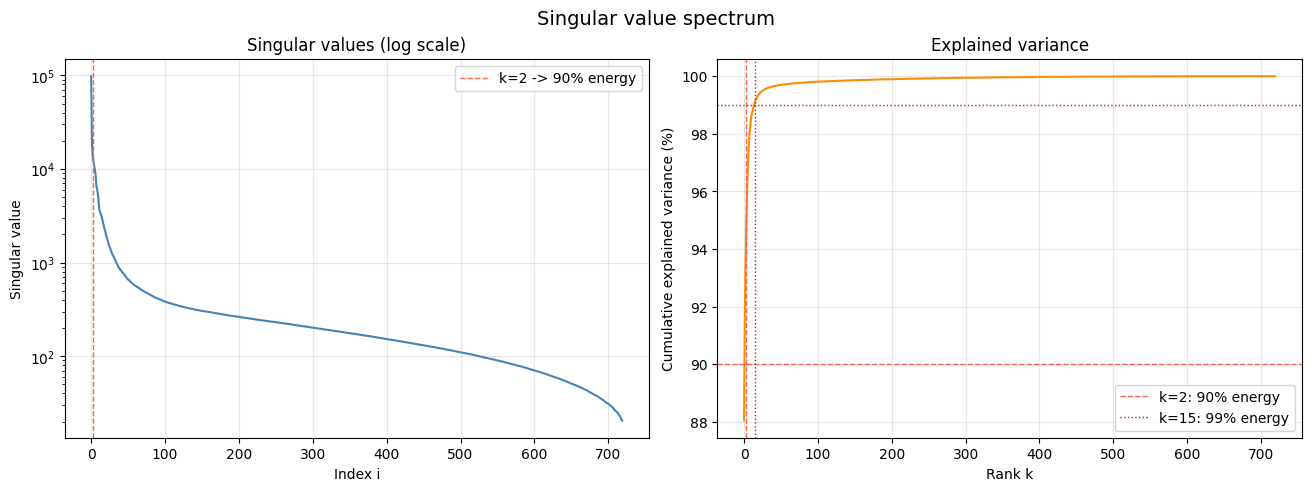


  k = 2  captures 90% of image energy  (out of 720 possible)
  k = 15  captures 99% of image energy
  Break-even k (no savings beyond this): 399


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
fig.suptitle("Singular value spectrum", fontsize=14)
 
ax = axes[0]
ax.plot(sv_mean, color='steelblue', linewidth=1.5)
ax.set_xlabel("Index i")
ax.set_ylabel("Singular value")
ax.set_title("Singular values (log scale)")
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
 
k90 = np.searchsorted(cumvar, 0.90) + 1
k99 = np.searchsorted(cumvar, 0.99) + 1
ax.axvline(k90, color='tomato', linestyle='--', linewidth=1,
           label=f'k={k90} -> 90% energy')
ax.legend()
 
ax2 = axes[1]
ax2.plot(cumvar * 100, color='darkorange', linewidth=1.5)
ax2.axhline(90, color='tomato', linestyle='--', linewidth=1)
ax2.axhline(99, color='firebrick', linestyle=':', linewidth=1)
ax2.axvline(k90, color='tomato', linestyle='--', linewidth=1,
            label=f'k={k90}: 90% energy')
ax2.axvline(k99, color='firebrick', linestyle=':', linewidth=1,
            label=f'k={k99}: 99% energy')
ax2.set_xlabel("Rank k")
ax2.set_ylabel("Cumulative explained variance")
ax2.set_title("Explained variance")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.show()
 
print(f"\n  k = {k90}  captures 90% of image energy  (out of {min(m,n)} possible)")
print(f"  k = {k99}  captures 99% of image energy")
print(f"  Break-even k (no savings beyond this): {compression_limit}")

Frobenius error (exact, from Eckart-Young theorem)

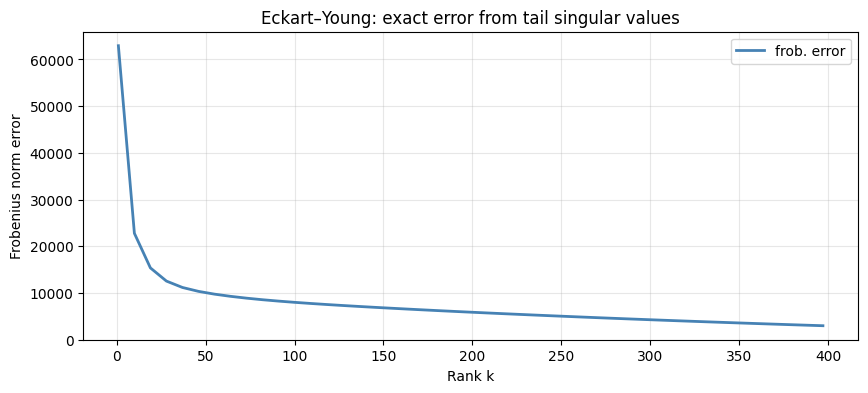

In [65]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_values, frob_errors, color='steelblue', linewidth=2,
        label='frob. error')
ax.set_xlabel("Rank k")
ax.set_ylabel("Frobenius norm error")
ax.set_title("Eckart–Young: exact error from tail singular values")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

SVD vs DCT: quality at equal storage budget

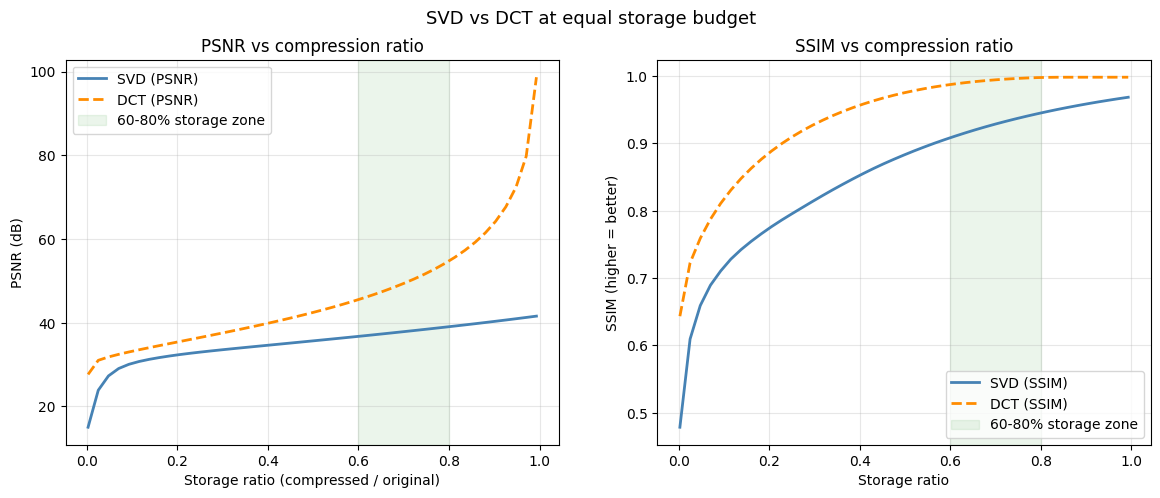

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SVD vs DCT at equal storage budget", fontsize=13)
 
ax = axes[0]
ax.plot(storage_ratios, psnr_svd, color='steelblue', linewidth=2, label='SVD (PSNR)')
ax.plot(storage_ratios, psnr_dct, color='darkorange', linewidth=2,
        linestyle='--', label='DCT (PSNR)')
ax.axvspan(0.60, 0.80, alpha=0.08, color='green', label='60-80% storage zone')
ax.set_xlabel("Storage ratio (compressed / original)")
ax.set_ylabel("PSNR (dB)")
ax.set_title("PSNR vs compression ratio")
ax.legend()
ax.grid(True, alpha=0.3)
 
ax2 = axes[1]
ax2.plot(storage_ratios, ssim_svd, color='steelblue', linewidth=2, label='SVD (SSIM)')
ax2.plot(storage_ratios, ssim_dct, color='darkorange', linewidth=2,
         linestyle='--', label='DCT (SSIM)')
ax2.axvspan(0.60, 0.80, alpha=0.08, color='green', label='60-80% storage zone')
ax2.set_xlabel("Storage ratio")
ax2.set_ylabel("SSIM (higher = better)")
ax2.set_title("SSIM vs compression ratio")
ax2.legend()
ax2.grid(True, alpha=0.3)
 
plt.show()

Rank-1 outer products 

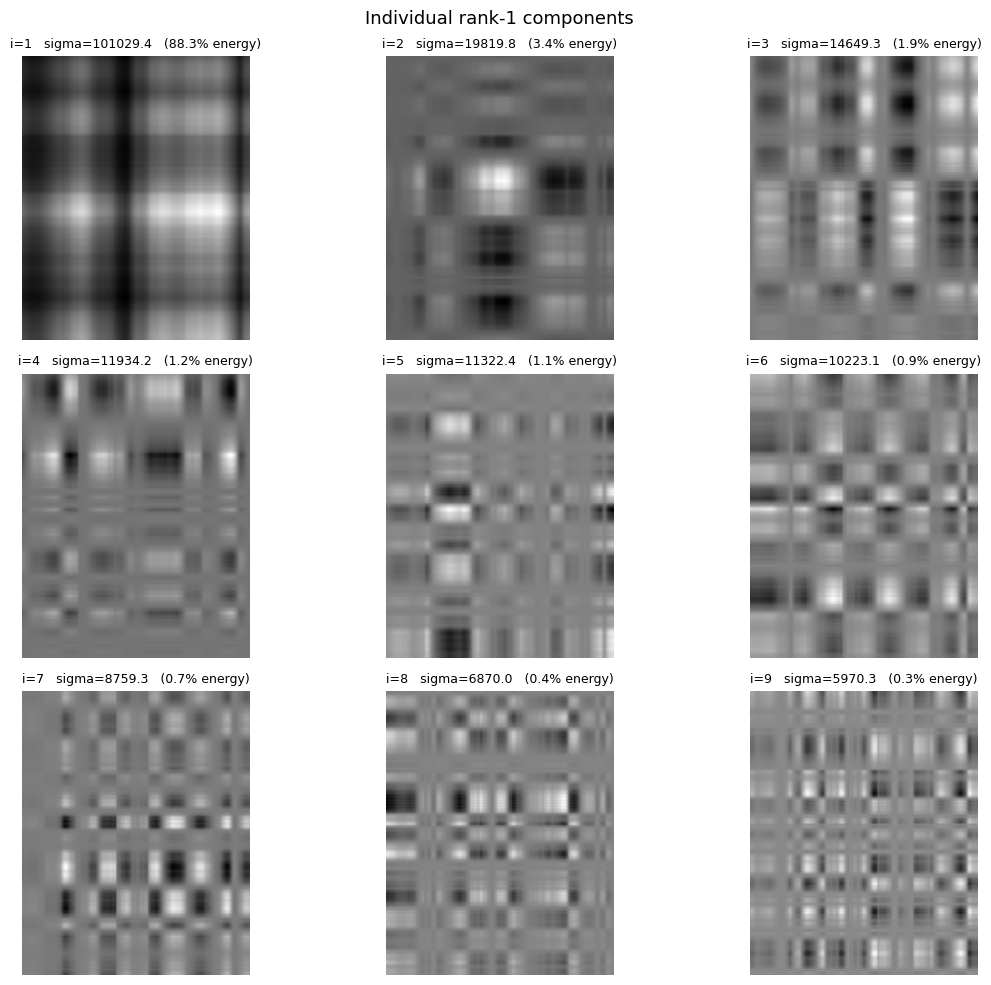

In [67]:
channel = image[:, :, 1]   # Green channel
U_ch, s_ch, Vt_ch = np.linalg.svd(channel, full_matrices=False)
 
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle("Individual rank-1 components",
             fontsize=13)
 
for idx, ax in enumerate(axes.flat):
    component = s_ch[idx] * np.outer(U_ch[:, idx], Vt_ch[idx, :])
    c_min, c_max = component.min(), component.max()
    display = (component - c_min) / (c_max - c_min + 1e-8) * 255
    ax.imshow(display, cmap='gray', vmin=0, vmax=255)
    energy_pct = (s_ch[idx] ** 2 / np.sum(s_ch ** 2)) * 100
    ax.set_title(f"i={idx+1}   sigma={s_ch[idx]:.1f}   ({energy_pct:.1f}% energy)",
                 fontsize=9)
    ax.axis('off')
 
plt.tight_layout()
plt.show()

Side-by-side visual grid at key k values

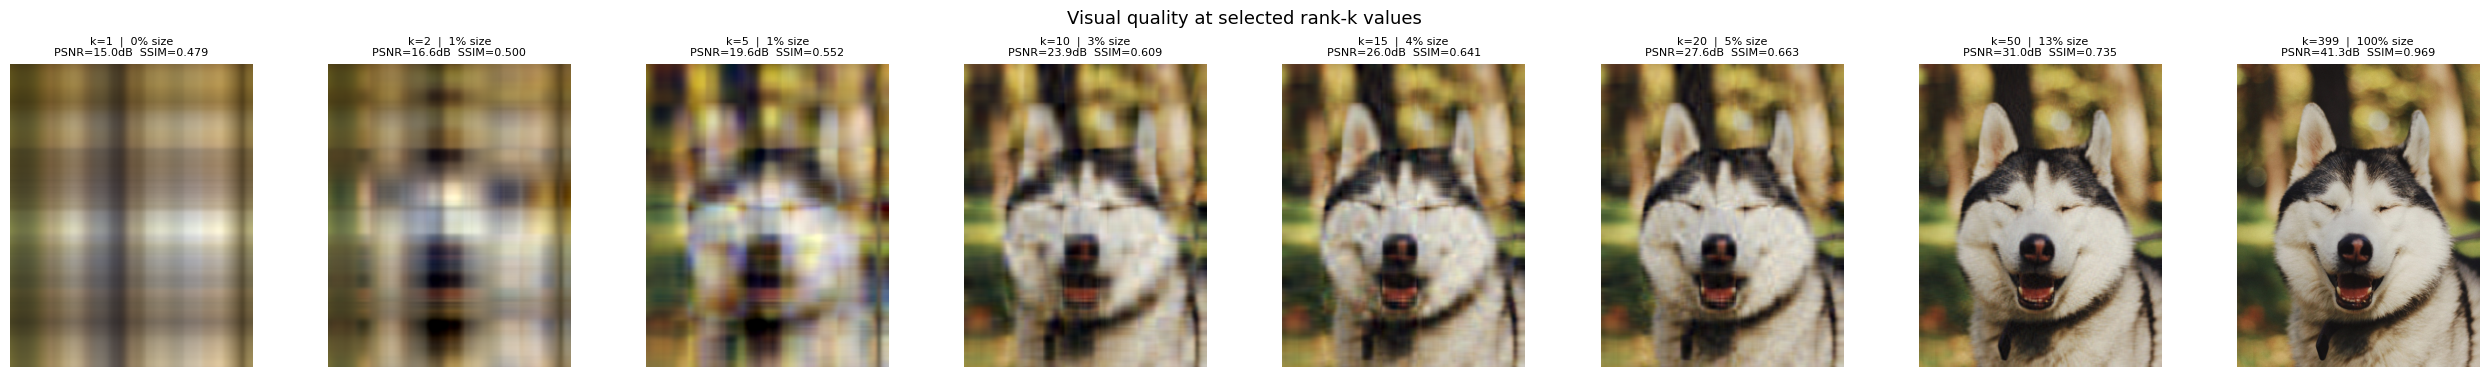

In [68]:
k_showcase = [1, 5, 10, 20, 50, k90, k99, compression_limit]
k_showcase = sorted(set(k for k in k_showcase if k <= min(m, n)))[:8]

fig, axes = plt.subplots(1, len(k_showcase), figsize=(3.2 * len(k_showcase), 3.8))
axes = np.atleast_1d(axes)
fig.suptitle("Visual quality at selected rank-k values", fontsize=13)
 
for ax, k in zip(axes, k_showcase):
    rec = reconstruct_image(image, k).astype(np.uint8)
    ax.imshow(cv.cvtColor(rec, cv.COLOR_BGR2RGB))
    p = psnr(image, rec.astype(np.float32))
    s_val = ssim_score(image, rec.astype(np.float32))
    ratio = compressed_size(k, image) / original_size
    ax.set_title(f"k={k}  |  {ratio*100:.0f}% size\nPSNR={p:.1f}dB  SSIM={s_val:.3f}",
                 fontsize=8)
    ax.axis('off')
 
plt.tight_layout()
plt.show()

Error heatmap

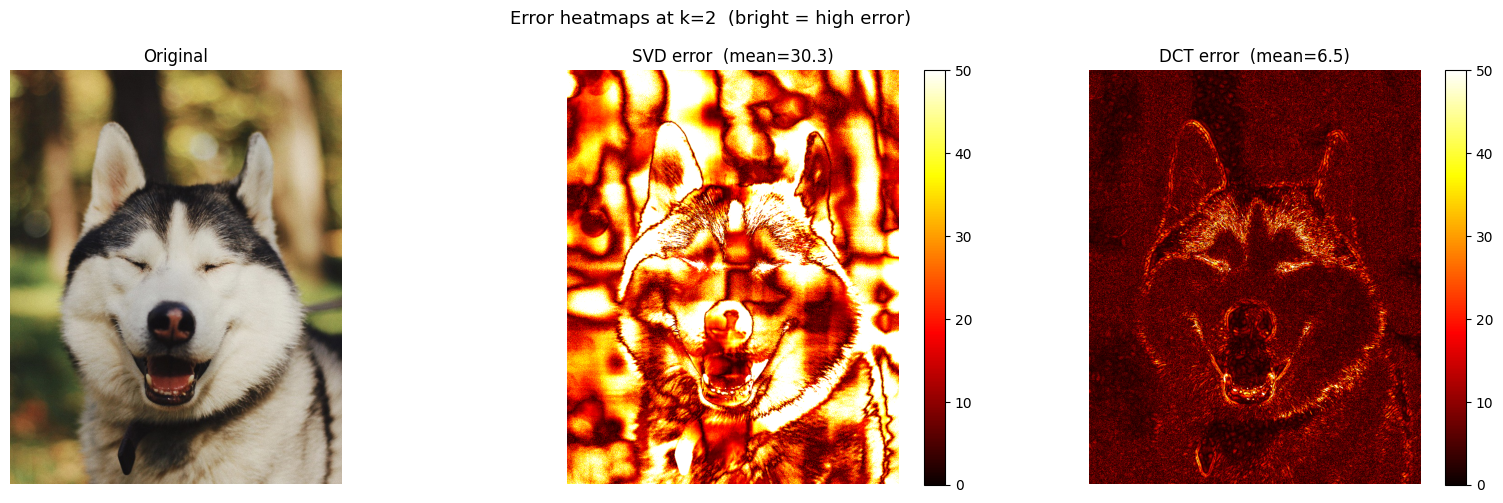

In [ ]:
k_demo = k90 
 
rec_svd_demo = reconstruct_image(image, k_demo)
rec_dct_demo = dct_compress_image(image, compressed_size(k_demo, image) / original_size)
 
err_svd = np.mean(np.abs(image - rec_svd_demo), axis=2)
err_dct = np.mean(np.abs(image - rec_dct_demo), axis=2)
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Error heatmaps at k={k_demo}  (bright = high error)", fontsize=13)
 
axes[0].imshow(cv.cvtColor(image.astype(np.uint8), cv.COLOR_BGR2RGB))
axes[0].set_title("Original"); axes[0].axis('off')
 
im1 = axes[1].imshow(err_svd, cmap='hot', vmin=0, vmax=50)
axes[1].set_title(f"SVD error  (mean={err_svd.mean():.1f})")
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
 
im2 = axes[2].imshow(err_dct, cmap='hot', vmin=0, vmax=50)
axes[2].set_title(f"DCT error  (mean={err_dct.mean():.1f})")
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)
 
plt.tight_layout()
plt.show()

Both SVD and DCT are lossy compression methods grounded in linear algebra, but they differ in one fundamental way: SVD finds the optimal basis for each specific image, while DCT uses the same fixed cosine basis for every image.
 
From the LA perspective - SVD wins by theorem.
The Eckart–Young theorem guarantees that the rank-k SVD approximation achieves the *minimum possible* Frobenius norm error among all rank-katrices. No fixed-basis method - including DCT - can beat SVD in this exact sense. SVD computes the data-adaptive directions $u_i, v_i$ that capture the most variance of *this particular image*, which is why it extracts information more efficiently per stored value.
 
In practice - DCT dominates.
Despite being theoretically optimal, DCT is the basis of JPEG and dominates real-world image compression. As noted by [Dilip Kumar](https://dilipkumar.medium.com/image-compression-using-singular-value-decomposition-svd-b074e1978505), there are three practical reasons for this: (1) DCT runs in $O(N \log N)$ via the Fast Fourier Transform, while computing full SVD costs $O(\min(m,n) \cdot mn)$; (2) DCT has a universal standardized format - every browser and OS can decode a JPEG; and (3) DCT quantization tables are specifically tuned to the human visual system, discarding frequencies the eye cannot detect anyway, which SVD's mathematically optimal truncation does not account for.
 


Summary table

In [70]:
print("\n" + "="*72)
print(f"{'Method':<8} {'Storage':>10} {'PSNR (dB)':>12} {'SSIM':>8} {'Frob Error':>12}")
print("="*72)
 
test_ks = [k90, k99]
for k in test_ks:
    ratio = compressed_size(k, image) / original_size
    rec_s = reconstruct_image(image, k)
    rec_d = dct_compress_image(image, ratio)
 
    print(f"SVD k={k:<4} {ratio*100:>8.1f}%  {psnr(image,rec_s):>10.2f}  "
          f"{ssim_score(image,rec_s):>8.4f}  "
          f"{frobenius_error_exact(image, k):>12.1f}")
    print(f"DCT={ratio*100:.0f}%  {ratio*100:>8.1f}%  {psnr(image,rec_d):>10.2f}  "
          f"{ssim_score(image,rec_d):>8.4f}  {'n/a':>12}")
    print("-"*72)
 
print(f"\nCondition number κ(image channel 0) = {s_ch[0]/s_ch[-1]:.1f}")



Method      Storage    PSNR (dB)     SSIM   Frob Error
SVD k=2         0.5%       16.55    0.4999       52926.5
DCT=1%       0.5%       28.96    0.6653           n/a
------------------------------------------------------------------------
SVD k=15        3.8%       26.00    0.6410       17812.5
DCT=4%       3.8%       31.51    0.7439           n/a
------------------------------------------------------------------------

Condition number κ(image channel 0) = 4987.6


SVD is the theoretically superior compressor from a linear algebra standpoint - it is provably optimal. DCT is the practically superior standard - it is fast, universal, and perceptually tuned. As noted in the [PhiWhyyy SVD vs DCT article](https://phiwhyyy.medium.com/svd-vs-dct-image-compression-78087dfe4c79), SVD shines in research and technical applications where customizability and accuracy are key, while DCT remains the go-to for general-purpose image handling. The rank-1 component visualizations further illustrate what SVD is actually doing: each outer product $\sigma_i u_i v_i^T$ is a global "layer" of the image, and summing the most energetic layers reconstructs the image progressively - exactly the picture Leo Wei's article describes when comparing rank-1, rank-10, and rank-100 approximations of the lighthouse image.

This is a space for your suggestions, comments, threats, etc...